# Employee Attrition Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict whether Employee  leaving or not the organization.

In [1]:
import pandas as pd
import numpy as np
EmployeeLeftData=pd.read_excel("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Classification Projects/Employee/Employee.xlsx")
print(EmployeeLeftData.shape)
print(EmployeeLeftData.drop_duplicates())
print(EmployeeLeftData.shape) 

(4653, 9)
      Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0     Bachelors         2017  Bangalore            3   34    Male          No   
1     Bachelors         2013       Pune            1   28  Female          No   
2     Bachelors         2014  New Delhi            3   38  Female          No   
3       Masters         2016  Bangalore            3   27    Male          No   
4       Masters         2017       Pune            3   24    Male         Yes   
...         ...          ...        ...          ...  ...     ...         ...   
4645    Masters         2017       Pune            2   31  Female          No   
4647  Bachelors         2016       Pune            3   30    Male          No   
4649    Masters         2013       Pune            2   37    Male          No   
4650    Masters         2018  New Delhi            3   27    Male          No   
4651  Bachelors         2012  Bangalore            3   30    Male         Yes   

      ExperienceI

In [2]:
EmployeeLeftData.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [3]:
EmployeeLeftData.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='object')

## Target Variable is LeaveOrNot

<Axes: xlabel='LeaveOrNot'>

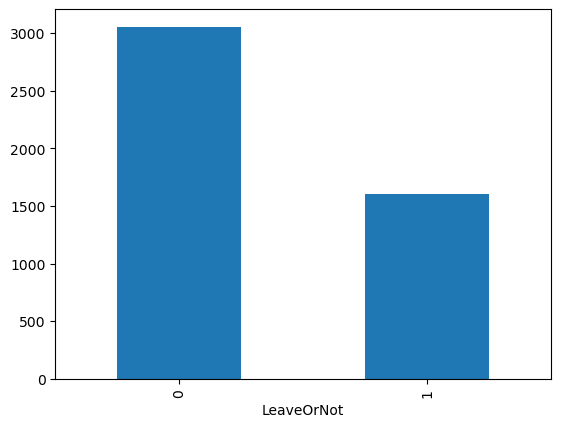

In [4]:
EmployeeLeftData.groupby('LeaveOrNot').size().plot(kind='bar')

## Good Distribution for ML

In [5]:
EmployeeLeftData.nunique()

Education                     3
JoiningYear                   7
City                          3
PaymentTier                   3
Age                          20
Gender                        2
EverBenched                   2
ExperienceInCurrentDomain     8
LeaveOrNot                    2
dtype: int64

## Categorical Columns: 'Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'
## Continous Columns: 'Age'

In [6]:
EmployeeLeftData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [7]:
EmployeeLeftData.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


## Uni Variate Analysis by Bar Charts

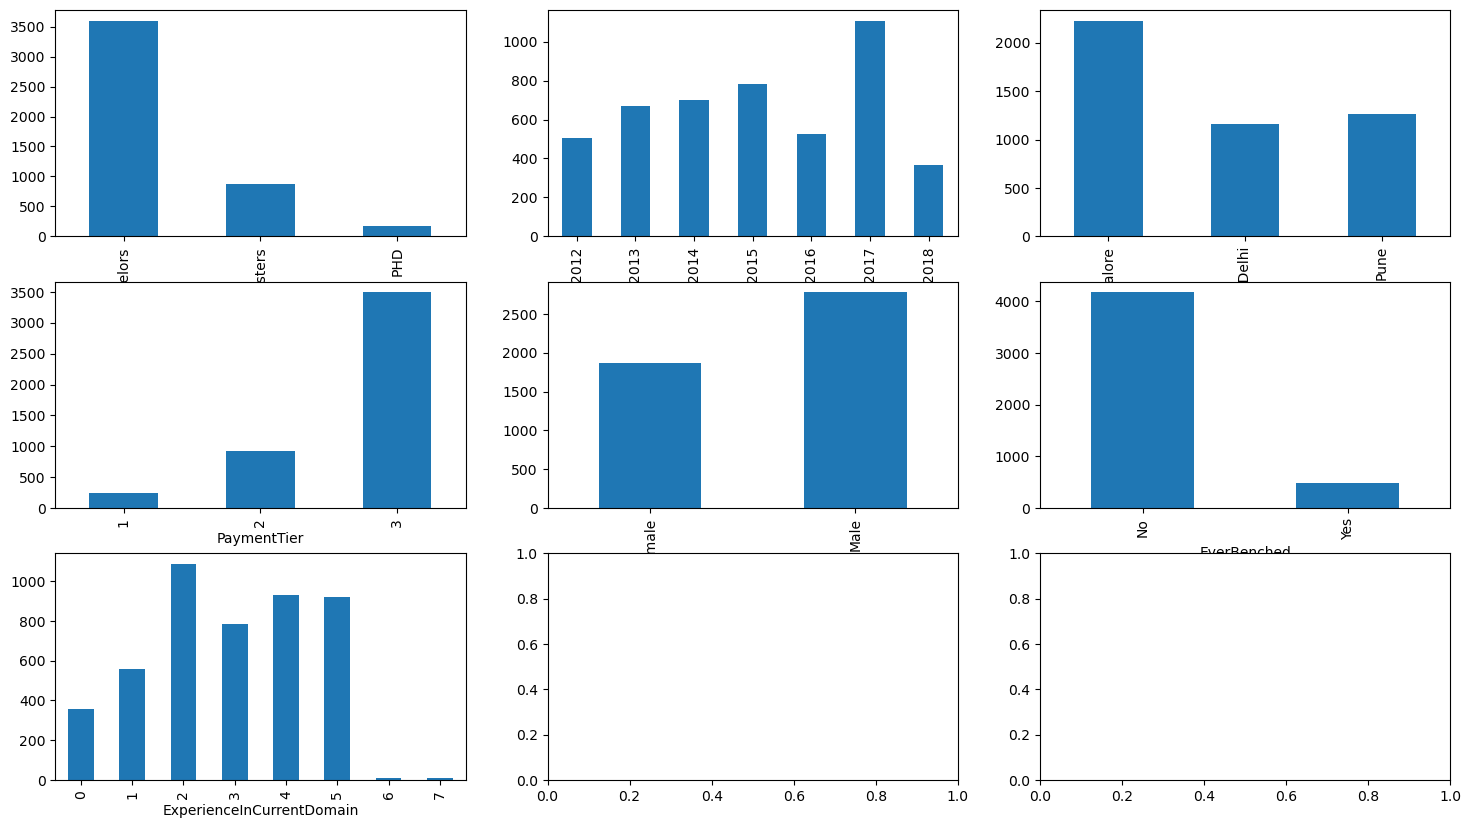

In [8]:
CategoricalColumns= ['Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(3,3,figsize=(18,10))
subplots=subplots.flatten()
for cols ,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    EmployeeLeftData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

### Can be eliminated:EverBenched

## Treating Imbalance

In [9]:
EmployeeLeftData.loc[EmployeeLeftData['ExperienceInCurrentDomain']>=5,'ExperienceInCurrentDomain']=5

<Axes: xlabel='ExperienceInCurrentDomain'>

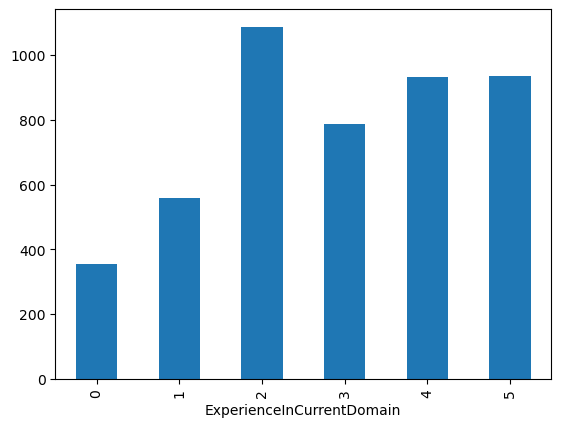

In [10]:
EmployeeLeftData.groupby('ExperienceInCurrentDomain').size().plot(kind='bar')

In [11]:
EmployeeLeftData['ExperienceInCurrentDomain']=EmployeeLeftData['ExperienceInCurrentDomain'].astype('str')

In [12]:
EmployeeLeftData['ExperienceInCurrentDomain']

0       0
1       3
2       2
3       5
4       2
       ..
4648    4
4649    2
4650    5
4651    2
4652    4
Name: ExperienceInCurrentDomain, Length: 4653, dtype: object

In [13]:
EmployeeLeftData.loc[EmployeeLeftData['ExperienceInCurrentDomain']=='5','ExperienceInCurrentDomain']='>5'

<Axes: xlabel='ExperienceInCurrentDomain'>

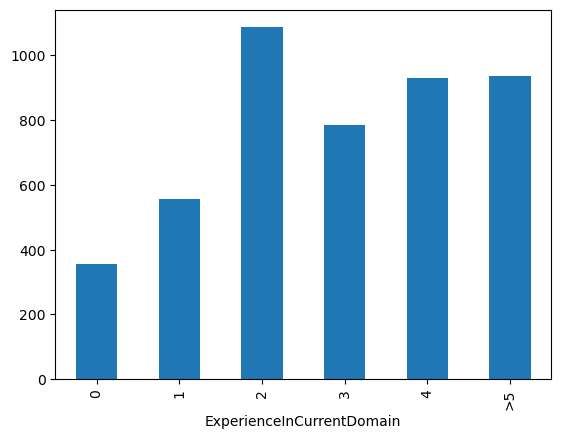

In [14]:
EmployeeLeftData.groupby('ExperienceInCurrentDomain').size().plot(kind='bar')

## Uni Variate Analysis by Histogram

In [15]:
EmployeeLeftData.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='object')

<Axes: >

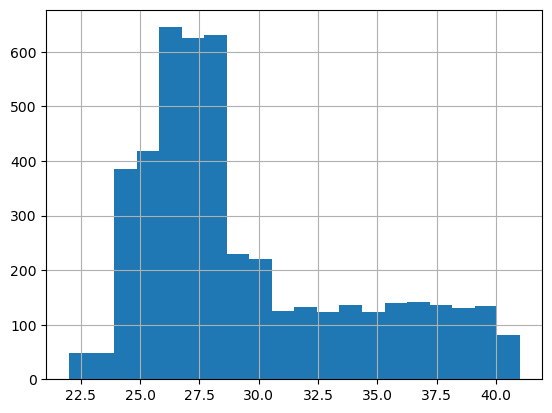

In [16]:
EmployeeLeftData['Age'].hist(bins=20)

## No need of Outlier treatment

In [17]:
EmployeeLeftData.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

## No need of Missing values treatment

## Categorical Vs Continuous -- Box Plots

<Axes: title={'center': 'Age'}, xlabel='LeaveOrNot'>

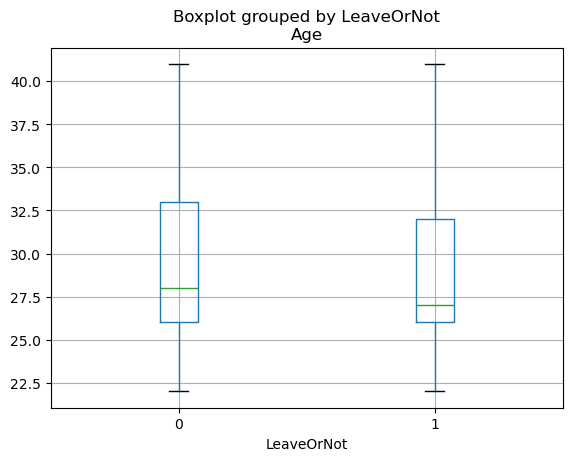

In [18]:
EmployeeLeftData.boxplot(column='Age',by='LeaveOrNot',vert=True)

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [19]:
def functionAnova(inpData,cols,targetVariable):
    SelectedPredictor=[]
    from scipy.stats import f_oneway
    CategoricalGroupLists=inpData.groupby(targetVariable)[cols].apply(list)
    AnovaResults=f_oneway(*CategoricalGroupLists)
    if AnovaResults[1]<0.05:
        print(cols,' is correlated with ',targetVariable, ' and p value is:',AnovaResults[1])
        SelectedPredictor.append(cols)
    else:
        print(cols,' is not correlated with ',targetVariable, ' and p value is:',AnovaResults[1])
    return SelectedPredictor
functionAnova(inpData=EmployeeLeftData,cols='Age',targetVariable='LeaveOrNot')

Age  is correlated with  LeaveOrNot  and p value is: 0.0004852123420637579


['Age']

## Relationship exploration: Categorical Vs Categorical -- Grouped Bar Charts

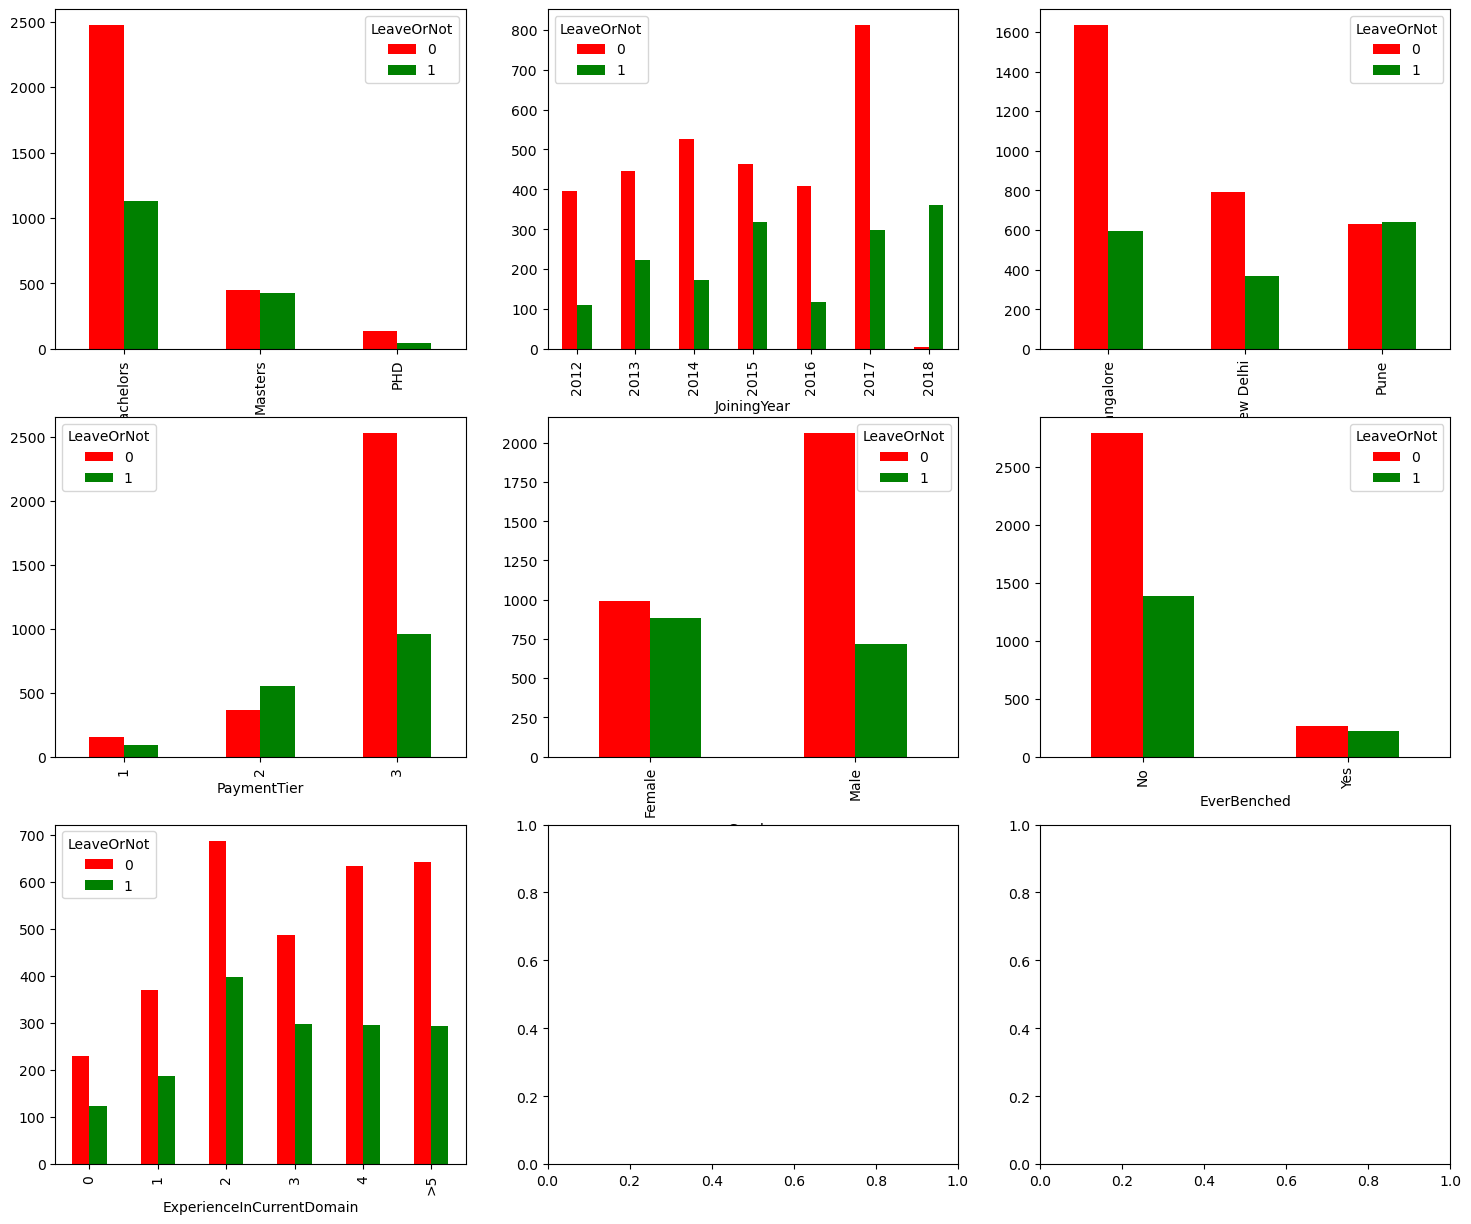

In [20]:
CategoricalColumns= ['Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(3,3,figsize=(18,15))
subplots=subplots.flatten()
for cols,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    crosstabresults=pd.crosstab(columns=EmployeeLeftData['LeaveOrNot'],index=EmployeeLeftData[cols])
    crosstabresults.plot.bar(color=['red','green'],ax=subplots[no_of_cols])

## Statistical Feature Selection (Categorical Vs Categorical) using Chi-Square Test

In [21]:
CategoricalColumns= ['Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain']
def chi_2_function(inpData,cols,targetVariable):
    from scipy.stats import chi2_contingency
    SelectedPredictors=[] 
    for cols in CategoricalColumns:
        CrossTabResult=pd.crosstab(columns=inpData[targetVariable],index=inpData[cols])
        chi2_results=chi2_contingency(CrossTabResult)
        if chi2_results[1]<0.05:
            print(cols,' is correlated with LeaveOrNot and p value is:',chi2_results[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with LeaveOrNot and p value is:',chi2_results[1])
    return SelectedPredictors
chi_2_function(inpData=EmployeeLeftData,cols=CategoricalColumns,targetVariable='LeaveOrNot')
    

Education  is correlated with LeaveOrNot and p value is: 7.724417739147332e-23
JoiningYear  is correlated with LeaveOrNot and p value is: 2.3266155616241426e-172
City  is correlated with LeaveOrNot and p value is: 1.7106992135618012e-45
PaymentTier  is correlated with LeaveOrNot and p value is: 2.9329904732261673e-74
Gender  is correlated with LeaveOrNot and p value is: 5.177873883438753e-51
EverBenched  is correlated with LeaveOrNot and p value is: 1.1603340647939294e-07
ExperienceInCurrentDomain  is correlated with LeaveOrNot and p value is: 0.016237426798472676


['Education',
 'JoiningYear',
 'City',
 'PaymentTier',
 'Gender',
 'EverBenched',
 'ExperienceInCurrentDomain']

In [22]:
EmployeeLeftData.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='object')

## Selecting final predictors for Machine Learning

In [23]:
SelectedColumns=['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender', 'EverBenched', 'ExperienceInCurrentDomain']
DataForMLEmployeeLeftData=EmployeeLeftData[SelectedColumns]
DataForMLEmployeeLeftData.to_pickle('DataForMLEmployeeLeftData.pkl')
DataForMLEmployeeLeftData=pd.read_pickle('DataForMLEmployeeLeftData.pkl') 
DataForMLEmployeeLeftData.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
0,Bachelors,2017,Bangalore,3,34,Male,No,0
1,Bachelors,2013,Pune,1,28,Female,No,3
2,Bachelors,2014,New Delhi,3,38,Female,No,2
3,Masters,2016,Bangalore,3,27,Male,No,>5
4,Masters,2017,Pune,3,24,Male,Yes,2


## Data Pre-processing for Machine Learning

## Converting the nominal variable to numeric using get_dummies()


In [24]:
DataForMLEmployeeLeftDataNumeric=pd.get_dummies(DataForMLEmployeeLeftData)

In [25]:
DataForMLEmployeeLeftDataNumeric.head()

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5
0,2017,3,34,True,False,False,True,False,False,False,True,True,False,True,False,False,False,False,False
1,2013,1,28,True,False,False,False,False,True,True,False,True,False,False,False,False,True,False,False
2,2014,3,38,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False
3,2016,3,27,False,True,False,True,False,False,False,True,True,False,False,False,False,False,False,True
4,2017,3,24,False,True,False,False,False,True,False,True,False,True,False,False,True,False,False,False


## Converting the binary nominal variable to numeric using 1/0 mapping

In [26]:
DataForMLEmployeeLeftDataNumeric.replace({True:1,False:0},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_103832\214777376.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForMLEmployeeLeftDataNumeric.replace({True:1,False:0},inplace=True)


In [27]:
DataForMLEmployeeLeftDataNumeric['LeaveOrNot']=EmployeeLeftData['LeaveOrNot']

In [28]:
DataForMLEmployeeLeftDataNumeric.head()

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,LeaveOrNot
0,2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
1,2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1
2,2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0
3,2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1
4,2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1


In [29]:
DataForMLEmployeeLeftDataNumeric.columns

Index(['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5', 'LeaveOrNot'],
      dtype='object')

## Machine Learning: Splitting the data into Training and Testing sample

In [30]:

predictors=['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5']
targetVariable='LeaveOrNot'
X=DataForMLEmployeeLeftDataNumeric[predictors].values
y=DataForMLEmployeeLeftDataNumeric[targetVariable].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=49,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3722, 19)
(3722,)
(931, 19)
(931,)


In [31]:
DataForMLEmployeeLeftDataNumeric.head(10)

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,LeaveOrNot
0,2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
1,2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1
2,2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0
3,2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1
4,2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1
5,2016,3,22,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
6,2015,3,38,1,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,0
7,2016,3,34,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1
8,2016,3,23,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
9,2017,2,37,0,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0


In [32]:
print(X_train[0:10])

[[2012    2   26    1    0    0    0    0    1    1    0    1    0    0
     0    0    0    1    0]
 [2016    3   38    1    0    0    1    0    0    1    0    1    0    0
     0    0    0    0    1]
 [2017    3   24    0    1    0    0    1    0    1    0    1    0    0
     0    1    0    0    0]
 [2013    3   40    1    0    0    0    0    1    1    0    1    0    0
     1    0    0    0    0]
 [2014    3   28    1    0    0    1    0    0    0    1    1    0    0
     0    1    0    0    0]
 [2017    3   27    1    0    0    1    0    0    0    1    1    0    0
     0    0    0    0    1]
 [2013    3   26    1    0    0    1    0    0    0    1    0    1    0
     0    0    0    1    0]
 [2015    2   28    1    0    0    0    1    0    1    0    0    1    0
     0    1    0    0    0]
 [2018    3   40    1    0    0    0    1    0    0    1    0    1    0
     0    0    0    1    0]
 [2014    1   26    1    0    0    0    0    1    0    1    1    0    0
     0    0    0    1    0]]

In [33]:
print(y_train[0:10])

[1 0 1 1 0 0 1 1 1 0]


## Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
# choose different values for solver 'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=20,penalty='l2', solver='newton-cg')
LOG=clf.fit(X_train, y_train) 
prediction=LOG.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test, prediction, average='weighted')
print('F1_Score:',np.round(F1_Score,2))
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',round(np.mean(AccuracyValues),2)*100,'%')

              precision    recall  f1-score   support

           0       0.73      0.91      0.81       598
           1       0.71      0.41      0.52       333

    accuracy                           0.73       931
   macro avg       0.72      0.66      0.67       931
weighted avg       0.73      0.73      0.71       931

[[543  55]
 [196 137]]
F1_Score: 0.71
[0.72316722 0.72395117 0.71202929 0.69114625 0.69871069]
Final Accuracy of the Model: 71.0 %


## Decision Tree 

              precision    recall  f1-score   support

           0       0.83      0.96      0.89       598
           1       0.90      0.65      0.75       333

    accuracy                           0.85       931
   macro avg       0.86      0.80      0.82       931
weighted avg       0.85      0.85      0.84       931

[[573  25]
 [116 217]]
F1_Score: 0.84
[0.83431957 0.85267583 0.86481067 0.8409995  0.84231679]
Final Accuracy of the Model: 85.0 %


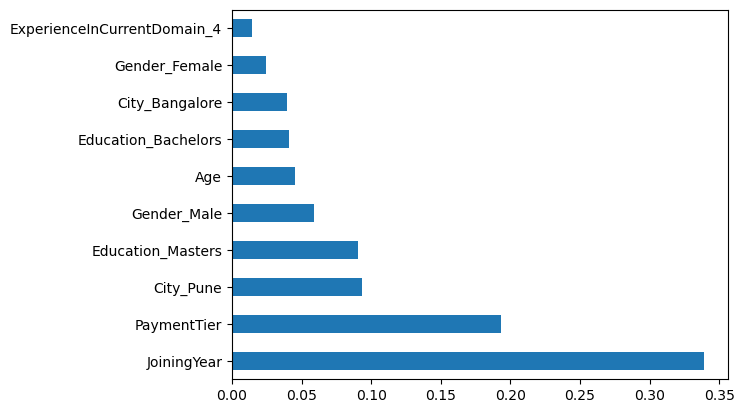

In [35]:
from sklearn import tree
# choose different values for solver 'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga' 
clf=tree.DecisionTreeClassifier(max_depth=8, criterion='entropy')
DT=clf.fit(X_train, y_train) 
Feature_Importances=pd.Series(DT.feature_importances_,index=predictors)
Feature_Importances.nlargest(10).plot(kind='barh')
prediction=DT.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test, prediction, average='weighted')
print('F1_Score:',np.round(F1_Score,2))
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DT,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',round(np.mean(AccuracyValues),2)*100,'%')

In [74]:
import matplotlib.pyplot as plt

## Random Forest Classifier

RandomForestClassifier(oob_score=True)
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       598
           1       0.81      0.67      0.73       333

    accuracy                           0.83       931
   macro avg       0.82      0.79      0.80       931
weighted avg       0.83      0.83      0.82       931

[[547  51]
 [110 223]]


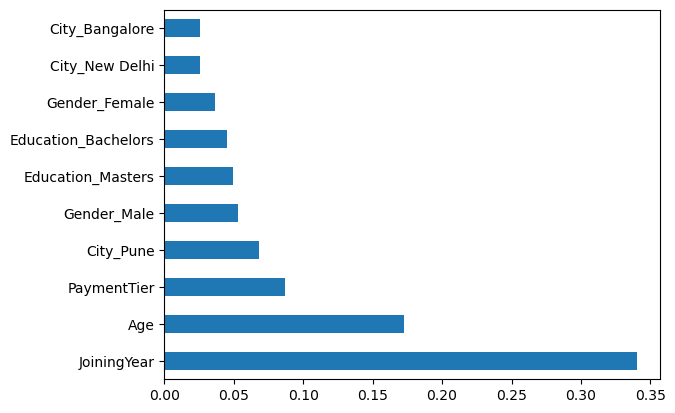

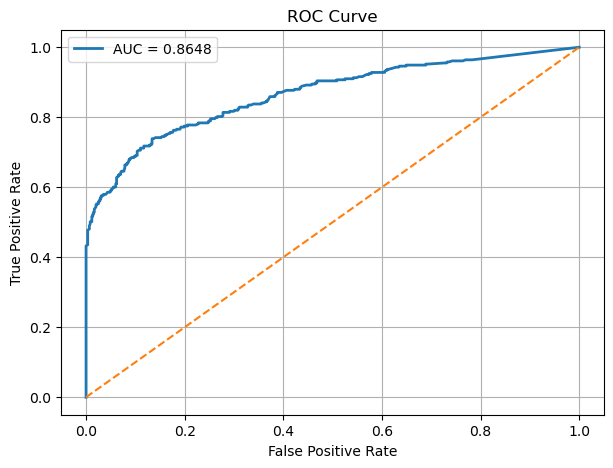

OOB Score: 83.0 %
OOB Error: 17.0 %
ROC-AUC Score: 0.8648


In [36]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100,criterion='gini', oob_score=True)
print(clf)
 
#Creating the model on Training Data
RF=clf.fit(X_train,y_train)
prediction=RF.predict(X_test)

#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction)) 
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['cardio']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()


from sklearn.metrics import roc_curve, roc_auc_score

y_prob = RF.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


OOBScore = RF.oob_score_

print("OOB Score:", round(OOBScore,2)*100,'%')

OOBError = 1 - OOBScore

print("OOB Error:", round(OOBError,2)*100,'%')


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

## XGBoost Classifier

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       598
           1       0.89      0.67      0.77       333

    accuracy                           0.85       931
   macro avg       0.8

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,...,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,TargetColumn,Prediction
0,2016,1,24,1,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,2014,3,37,1,0,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2,2013,3,26,1,0,0,1,0,0,1,...,1,0,0,0,0,0,1,0,0,0
3,2012,3,34,0,1,0,0,1,0,1,...,1,0,0,0,0,1,0,0,0,0
4,2016,3,25,1,0,0,1,0,0,1,...,1,0,0,0,0,1,0,0,0,0


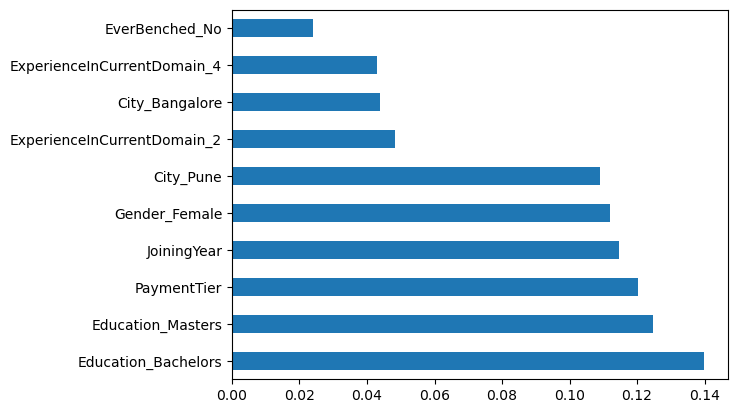

In [48]:
###### Xgboost Classification in Python #######
import pandas as pd 
from xgboost import XGBClassifier
clf=XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=400, objective='binary:logistic', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(clf)
 
#Creating the model on Training Data                                                                                                         

XGB=clf.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))

print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()
print('Final Accuracy of the Model:',round(metrics.f1_score(y_test, prediction,average='weighted'),4)*100,"%")

## Ada Boost Classifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                   learning_rate=0.08, n_estimators=500)
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       598
           1       0.89      0.67      0.76       333

    accuracy                           0.85       931
   macro avg       0.86      0.81      0.83       931
weighted avg       0.86      0.85      0.85       931

[[569  29]
 [109 224]]


,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,...,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,TargetColumn,Prediction
0,2016,1,24,1,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,2014,3,37,1,0,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2,2013,3,26,1,0,0,1,0,0,1,...,1,0,0,0,0,0,1,0,0,0
3,2012,3,34,0,1,0,0,1,0,1,...,1,0,0,0,0,1,0,0,0,0
4,2016,3,25,1,0,0,1,0,0,1,...,1,0,0,0,0,1,0,0,0,0


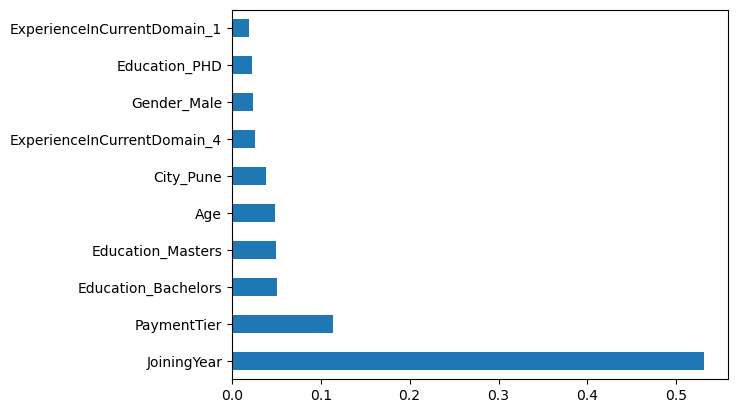

In [58]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
 
#Choosing Decision Tree with 1 level as the weak learner
DTC=DecisionTreeClassifier(max_depth=5)
clf = AdaBoostClassifier(n_estimators=500, estimator=DTC ,learning_rate=0.08)
 
#Printing all the parameters of Adaboost
print(clf)
 
#Creating the model on Training Data
AB=clf.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()




## Selected Logistic Rgression Model for Deployment:Random Forest Classifier

## Deploying on Sample Production Data

In [59]:
NewData=pd.DataFrame(data=[
[2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0],
[2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0],
[2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0],
[2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1],
[2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0],
[2016,3,22,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0],
[2015,3,38,1,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0],
[2016,3,34,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0],
[2016,3,23,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0],
[2017,2,37,0,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0],
[2018,2,29,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0],
[2015,1,31,0,1,0,0,0,1,0,1,0,1,0,1,0,0,0,0],
[2014,3,41,1,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0],
[2018,3,26,1,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0],
[2019,2,25,0,1,0,0,0,1,1,0,0,1,0,0,0,1,0,0],
[2017,3,35,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,1],
[2013,1,30,1,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0],
[2015,2,33,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0],
[2016,3,28,0,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0],
[2018,3,24,1,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0]
],columns=['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5'])

In [25]:
DataForMLEmployeeLeftDataNumeric.columns

Index(['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5', 'LeaveOrNot'],
      dtype='str')

In [60]:
newX=NewData.values

In [61]:
XGB.predict(newX)

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1])

In [62]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [63]:
GenerateSurvialPred(inpData=NewData)


,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,Prediction
0,2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
1,2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1
2,2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0
3,2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1
4,2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1
5,2016,3,22,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
6,2015,3,38,1,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,0
7,2016,3,34,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0
8,2016,3,23,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
9,2017,2,37,0,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0
